In [ ]:
import matplotlib.pyplot as plt
import math

In [ ]:
#Parâmetros gerador de números pseudoaleatórios:
a = 2023
c = 8
M = 2**32
X0 = 12345
n = 100000

In [ ]:
def NextRandom() -> float:
  global previous
  previous = ((a * previous) + c) % M
  return previous / M

In [ ]:
pseudoAleatorios = [] #vetor que vai armazenar esses valores uniformizados entre 0 e 1

In [ ]:
previous = X0

In [ ]:
pseudoAleatorios.append(X0 / M)

In [ ]:
for i in range(1, n): #função que popula o vetor
    pseudoAleatorios.append(NextRandom());

In [ ]:
for i in range(6):
    print(f"{pseudoAleatorios[i]}")

2.8742942959070206e-06
0.005814699223265052
0.763136530527845
0.8252012596931309
0.3821483610663563
0.0861344391014427


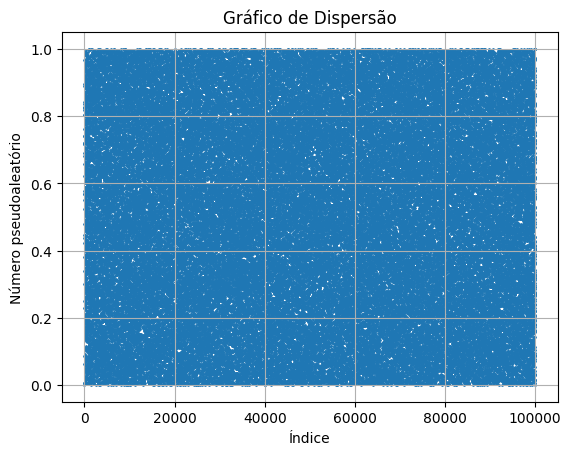

In [ ]:
plt.scatter(range(n), pseudoAleatorios, s= 1.0)

plt.title("Gráfico de Dispersão")
plt.xlabel("Índice")
plt.ylabel("Número pseudoaleatório")
plt.grid(True)

plt.show()

In [ ]:
indice_aleatorio = 0

In [ ]:
#Define qual será o proximo pseudoaleatório usado:
def numeroUsado():
  """Consome o próximo número do vetor, na ordem."""
  global indice_aleatorio

  if indice_aleatorio >= len(pseudoAleatorios):
      return None

  numero = pseudoAleatorios[indice_aleatorio]
  indice_aleatorio += 1

  return numero

In [ ]:
#gera numero distribuido entre a e b a partir do pseudoaleatorio
def converte(a, b):
    """Transforma o próximo aleatório de [0,1) em um valor de [a,b]."""
    u = numeroUsado()

    if u is None:
        return None

    return a + u * (b - a)

In [ ]:
relogio = 0.0
n_sistema = 0
fila_espera = 0
saidas_agendadas = []
proxima_chegada = 0.0
perdas = 0
tempo_acumulado_por_estado = []

In [ ]:
def chegada():
    global n_sistema, fila_espera, proxima_chegada, perdas

    if n_sistema < capacidade_fila:

        n_sistema += 1 #adiciona cliente ao sistema

        # procura um servidor livre
        livre = next(
            (i for i, t in enumerate(saidas_agendadas) #itera sobre as saidas_agendadas procurandi math.int (livre)
             if t == math.inf),
            None #se nao encontra, retorna None
        )

        if livre is not None:

            tempo_servico = converte(*faixa_saida)

            if tempo_servico is not None:
                saidas_agendadas[livre] = (#se houver algum livre, agenda saída nesse servidor (adiciona na lista)
                    relogio + tempo_servico #soma
                )

        else:
            fila_espera += 1 #senão, adiona o cliente na fila de espera

    else:
        perdas += 1 #se o sistema estpá cheio, há perda

    # agenda próxima chegada
    intervalo = converte(*faixa_chegada)

    if intervalo is not None:
        proxima_chegada = relogio + intervalo #adiciona na lista
    else:
        proxima_chegada = math.inf

In [ ]:
def saida(idx_servidor): #idx servidor é o servidor onde está acontecendo o atendimento
    global n_sistema, fila_espera

    n_sistema -= 1 #decrementa a quantidade de clientes no sistema

    saidas_agendadas[idx_servidor] = math.inf #libera o servidor

    if fila_espera > 0: #se houver gente esperando na fila, agenda outra saída nesse servidor

        tempo_servico = converte(*faixa_saida)

        if tempo_servico is not None:

            fila_espera -= 1

            saidas_agendadas[idx_servidor] = (relogio + tempo_servico)

In [ ]:
#Escalonador, decide qual o pŕoximo evento (menor tempo) que vai para a simulação:
def nextEvent():
    global num_servidores, saidas_agendadas, proxima_chegada

    idx_saida = min( #encontra qual servidor tem a saída marcada com menor tempo e retorna o índice na lista de saídas agendadas correspondente
        range(num_servidores),
        key=lambda i: saidas_agendadas[i]
    )

    tempo_saida = saidas_agendadas[idx_saida]

    if proxima_chegada <= tempo_saida:
        return ("chegada", None, proxima_chegada)
    else:
        return ("saida", idx_saida, tempo_saida)


In [ ]:
def simula(servidores, capacidade, chegada_range, saida_range, primeira_chegada=3.0):

    #RESETA PARAMETROS:

    global capacidade_fila
    global num_servidores
    global faixa_chegada
    global faixa_saida

    global relogio
    global n_sistema
    global fila_espera
    global saidas_agendadas
    global proxima_chegada
    global perdas

    global tempo_acumulado_por_estado
    global indice_aleatorio

    capacidade_fila = capacidade
    num_servidores = servidores

    faixa_chegada = chegada_range
    faixa_saida = saida_range

    # começa novamente do primeiro número
    indice_aleatorio = 0

    # RESET DO ESTADO
    relogio = 0.0 #tempo total de simulação
    n_sistema = 0 #quantidade de clientes dentro do sistema (variável K)
    fila_espera = 0

    saidas_agendadas = [math.inf] * servidores #math.inf significa servidores livres
    #saidas_agendadas é uma lista que guarda o horário em que cada servidor terminará seu atendimento

    proxima_chegada = primeira_chegada
    #proxima_chegada é uma variável que guarda o horário em que o próximo cliente vai chegar ao sistema

    perdas = 0

    tempo_acumulado_por_estado = [0.0] * (capacidade + 1) #lista em que cada posição guarda quanto tempo a simulação ficou naquele estado (inicializa com zero)

    #LOOP PRINCIPAL:
    while indice_aleatorio < len(pseudoAleatorios):
        #descobre qual evento acontecerá primeiro e armazena qual o tipo de evento, indice do servidor e
        tipo, idx, tempo_evento = nextEvent()

        # se não há mais eventos, encerra
        if math.isinf(tempo_evento):
            break

        #acumula o tempo que o sistema permaneceu no estado atual
        tempo_acumulado_por_estado[n_sistema] += (tempo_evento - relogio)

        #atualiza o relógio
        relogio = tempo_evento

        # executa o evento
        if tipo == "chegada":
            chegada()
        else:
            saida(idx)

    #CALCULA AS PROBABILIDADES
    probabilidades = [
        t / relogio
        for t in tempo_acumulado_por_estado
    ]

    return {

        "tempo_global":
            relogio,
        "tempo_acumulado_por_estado":
            list(tempo_acumulado_por_estado),
        "probabilidades":
            probabilidades,
        "perdas":
            perdas,
        "aleatorios_usados":
            indice_aleatorio
    }

In [ ]:
def imprime_resultado(nome,resultado,capacidade):

    print(f"\n===== {nome} =====")

    print(
        f"Aleatórios consumidos: "
        f"{resultado['aleatorios_usados']}"
    )

    print(
        f"Tempo global de simulação: "
        f"{resultado['tempo_global']:.4f}"
    )

    print(
        f"Número de clientes perdidos: "
        f"{resultado['perdas']}"
    )

    print(
        f"{'Estado':>8} "
        f"{'Tempo acumulado':>18} "
        f"{'Probabilidade':>15}"
    )

    for i in range(capacidade + 1):

        print(
            f"{i:>8} "
            f"{resultado['tempo_acumulado_por_estado'][i]:>18.4f} "
            f"{resultado['probabilidades'][i]:>15.6f}"
        )

    print(
        f"Soma das probabilidades: "
        f"{sum(resultado['probabilidades']):.6f}"
    )

In [ ]:
r1 = simula(
    servidores=1,
    capacidade=5,
    chegada_range=(3, 5),
    saida_range=(4, 5),
    primeira_chegada=3.0
)

imprime_resultado(
    "G/G/1/5",
    r1,
    capacidade=5)


===== G/G/1/5 =====
Aleatórios consumidos: 100000
Tempo global de simulação: 211793.9300
Número de clientes perdidos: 5911
  Estado    Tempo acumulado   Probabilidade
       0             3.0000        0.000014
       1            15.4266        0.000073
       2            39.8455        0.000188
       3           617.5099        0.002916
       4        101339.4440        0.478481
       5        109778.7040        0.518328
Soma das probabilidades: 1.000000


In [ ]:
r2 = simula(
    servidores=2,
    capacidade=5,
    chegada_range=(3, 5),
    saida_range=(4, 5),
    primeira_chegada=3.0
)

imprime_resultado(
    "G/G/2/5",
    r2,
    capacidade=5
)


===== G/G/2/5 =====
Aleatórios consumidos: 100000
Tempo global de simulação: 200068.6755
Número de clientes perdidos: 0
  Estado    Tempo acumulado   Probabilidade
       0          4227.5601        0.021131
       1        166638.4553        0.832906
       2         29202.6601        0.145963
       3             0.0000        0.000000
       4             0.0000        0.000000
       5             0.0000        0.000000
Soma das probabilidades: 1.000000
